In [1]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import CIFAR100
from pathlib import Path
import os
from PIL import Image
import matplotlib.pyplot as plt
import random

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
train_transform = transforms.Compose([transforms.Resize((32,32)), transforms.RandomHorizontalFlip(p=0.5), transforms.RandomRotation(15),
                               transforms.RandomCrop(32,padding=4,padding_mode='reflect'),transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((32,32)), transforms.ToTensor()])

In [4]:
train_data = CIFAR100(root='data', train=True, download=True, transform=train_transform)
test_data = CIFAR100(root='data', train=False, download=True, transform=test_transform)

In [6]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=0)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=0)

In [8]:
class CifarModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(nn.Conv2d(3,32,kernel_size=3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.Conv2d(32,32,kernel_size=3,padding=1), 
                                    nn.BatchNorm2d(32),nn.ReLU(), nn.Dropout(p=0.25),nn.MaxPool2d(kernel_size=2))
        self.layer2 = nn.Sequential(nn.Conv2d(32,64,kernel_size=3,padding=1), nn.BatchNorm2d(64),nn.ReLU(), nn.Conv2d(64,64,kernel_size=3,padding=1), 
                                    nn.BatchNorm2d(64),nn.ReLU(), nn.Dropout(p=0.25),nn.MaxPool2d(kernel_size=2))
        self.layer3 = nn.Sequential(nn.Flatten(), nn.Dropout(p=0.5), nn.Linear(64*8*8, 512), nn.BatchNorm1d(512),
                                    nn.ReLU(), nn.Linear(512,100))
    def forward(self, x):
        x1 = self.layer1(x)
        x2 = self.layer2(x1)
        return self.layer3(x2)
model = CifarModel().to(device)

In [9]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [10]:
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=20,gamma=0.2)

In [11]:
def acc_fn(pred,y):
    pred = pred.argmax(dim=1)
    acc = torch.eq(pred,y).sum().item()/len(pred)
    return acc*100

In [12]:
def train_step(model,dataloader=train_dataloader,loss_fn=loss_fn,optimizer=optimizer,device=device):
    model.train()
    acc = 0
    floss = 0
    for X,y in dataloader:
        X,y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = loss_fn(logits,y)
        loss.backward()
        optimizer.step()
        acc += acc_fn(logits, y)
        floss +=loss.item()
    return floss / len(dataloader), acc / len(dataloader)

def test_step(model,dataloader=test_dataloader,loss_fn=loss_fn, device=device):
    model.eval()
    acc = 0
    floss = 0
    with torch.inference_mode():
        for X,y in dataloader:
            X,y = X.to(device), y.to(device)
            logits = model(X)
            loss = loss_fn(logits,y)
            acc += acc_fn(logits, y)
            floss += loss.item()
        return floss / len(dataloader), acc / len(dataloader)



In [34]:
for epoch in range(51):
    train_loss, train_acc = train_step(model,optimizer=optimizer)
    test_loss, test_acc = test_step(model)
    scheduler.step()
    print(f'Epoch {epoch}\nTrain loss: {train_loss} Test loss: {test_loss}\nTrain acc:{train_acc} Test acc: {test_acc}')

Epoch 0
Train loss: 3.5486216391040513 Test loss: 3.2266296167343187
Train acc:15.78095009596929 Test acc: 22.753594249201278
Epoch 1
Train loss: 3.0141845814173447 Test loss: 2.778722708217633
Train acc:25.43186180422265 Test acc: 31.918929712460063
Epoch 2
Train loss: 2.779903060491468 Test loss: 2.747981218484263
Train acc:29.860444657709532 Test acc: 30.94049520766773
Epoch 3
Train loss: 2.6034882433965127 Test loss: 2.4991302052244975
Train acc:33.29934420985285 Test acc: 35.77276357827476
Epoch 4
Train loss: 2.465044719243919 Test loss: 2.345028325772514
Train acc:36.44833653230966 Test acc: 39.92611821086262
Epoch 5
Train loss: 2.3754148215570283 Test loss: 2.278604676167424
Train acc:38.189779270633395 Test acc: 41.40375399361022
Epoch 6
Train loss: 2.284744262619043 Test loss: 2.2110281611402955
Train acc:40.09317018554063 Test acc: 42.581869009584665
Epoch 7
Train loss: 2.2184946128975787 Test loss: 2.1111615801009886
Train acc:41.62068138195777 Test acc: 45.027955271565496
E

In [35]:
torch.save(model.state_dict(), 'model_weights.pth')

In [14]:
model2 = CifarModel()
state_dict = torch.load('model_weights.pth',map_location=device)
model2.load_state_dict(state_dict=state_dict)

<All keys matched successfully>

In [15]:
classes = train_data.classes

Prediction: seal
Label: seal


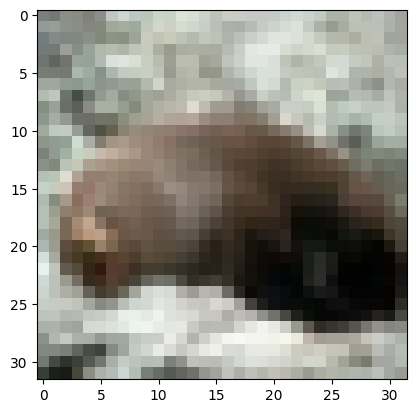

In [33]:
model2.eval()
with torch.inference_mode():
    img, label = test_data[random.randint(0,len(test_data)-1)]
    logits = model2(img.unsqueeze(dim=0))
    prediction = torch.argmax(logits,dim=1)
    plt.imshow(img.permute(1,2,0))
    print(f'Prediction: {classes[prediction.item()]}\nLabel: {classes[label]}')